# 03 — Feature Engineering
**Objectif :** Créer 13 nouvelles variables à partir des données brutes pour enrichir l'information fournie aux modèles ML.

In [1]:
# ── Chargement & Nettoyage ────────────────────────────────────
import pandas as pd, numpy as np

df = pd.read_csv('Gasification Dataset.csv', delimiter=';')
df.columns = df.columns.str.strip()
for c in df.select_dtypes('object').columns:
    df[c] = df[c].str.strip()
df.loc[df['Hydrogen'] < 0, 'Hydrogen'] = 0.0
print(f"Dataset charge : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}  |  Doublons : {df.duplicated().sum()}")

# ── Experiment_Group + Shuffle ────────────────────────────────
group_cols = ['ProcessTemperature','AgentType','AgentFlow',
              'SampleType','CatalystType','CatalystRatio']
df['Experiment_Group'] = df.groupby(group_cols).ngroup()
df = df.sort_values(['Experiment_Group','Time']).reset_index(drop=True)

rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(df['Experiment_Group'].unique())
remap = {old: new for new, old in enumerate(shuffled_ids)}
df['Experiment_Group'] = df['Experiment_Group'].map(remap)
print(f"Groupes identifies : {df['Experiment_Group'].nunique()} experiences")

Dataset charge : 3748 lignes × 9 colonnes
Valeurs manquantes : 0  |  Doublons : 0
Groupes identifies : 59 experiences


## Pourquoi le Feature Engineering ?
Les variables originales ne capturent pas directement l'énergie thermique cumulée, qui est le facteur dominant de la production H2 (confirmé par SHAP).

In [2]:
# ── Feature Engineering ───────────────────────────────────────
g     = df.groupby('Experiment_Group')
max_t = g['Time'].transform('max')

df['Relative_Time']         = df['Time'] / (max_t + 1e-6)
df['Thermal_Work']          = df['Temperature'] * df['Time']
df['Agent_Intensity']       = df['AgentFlow'] * df['ProcessTemperature']
df['Thermal_Acceleration']  = df['Thermal_Work'] / (df['Time'] + 0.1)
df['Relative_Severity']     = df['Relative_Time'] * df['ProcessTemperature']
df['Kinetic_Agent_Density'] = df['AgentFlow'] * df['Relative_Time']
df['Cumul_Temp']            = g['Temperature'].cumsum()
df['Temp_Norm_in_Run']      = g['Temperature'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))
df['Temp_x_AgentFlow']      = df['Temperature'] * df['AgentFlow']
df['Temp_x_CatalystRatio']  = df['Temperature'] * df['CatalystRatio']
df['Cumul_x_AgentFlow']     = df['Cumul_Temp']  * df['AgentFlow']
df['Temp_squared']          = df['Temperature'] ** 2
df['Cumul_Temp_squared']    = df['Cumul_Temp']  ** 2
df['Temp_mean_run']         = g['Temperature'].transform('mean')
df['Temp_max_run']          = g['Temperature'].transform('max')
df['Temp_std_run']          = g['Temperature'].transform('std').fillna(0)

num_cols = [
    'Time','Temperature','ProcessTemperature','AgentFlow','CatalystRatio',
    'Relative_Time','Thermal_Work','Agent_Intensity',
    'Thermal_Acceleration','Relative_Severity','Kinetic_Agent_Density',
    'Cumul_Temp','Temp_Norm_in_Run',
    'Temp_x_AgentFlow','Temp_x_CatalystRatio','Cumul_x_AgentFlow',
    'Temp_squared','Cumul_Temp_squared',
    'Temp_mean_run','Temp_max_run','Temp_std_run',
]
cat_cols = ['AgentType','SampleType','CatalystType']
X      = df[num_cols + cat_cols]
y      = df['Hydrogen']
groups = df['Experiment_Group']
print(f"Features : {len(num_cols)} numeriques + {len(cat_cols)} categorielles = {len(num_cols)+len(cat_cols)} total")

Features : 21 numeriques + 3 categorielles = 24 total


In [3]:
# ── Corrélations des nouvelles features avec H2 ────────────────
from scipy import stats
import matplotlib.pyplot as plt

print("=== CORRELATIONS AVEC H2 (Pearson r) ===")
new_feats = ['Cumul_Temp','Thermal_Work','Temp_squared','Cumul_Temp_squared',
             'Relative_Time','Thermal_Acceleration','Temp_Norm_in_Run',
             'Temp_x_AgentFlow','Temp_x_CatalystRatio','Temp_mean_run']

results = []
for feat in new_feats:
    r, p = stats.pearsonr(df[feat], df['Hydrogen'])
    results.append((feat, r, p))
    flag = "✅" if abs(r) > 0.3 else "🟡" if abs(r) > 0.1 else "⚪"
    print(f"  {flag} {feat:30s} : r = {r:+.3f}  p = {p:.4f}")

=== CORRELATIONS AVEC H2 (Pearson r) ===
  ✅ Cumul_Temp                     : r = +0.427  p = 0.0000
  ✅ Thermal_Work                   : r = +0.502  p = 0.0000
  ✅ Temp_squared                   : r = +0.691  p = 0.0000
  🟡 Cumul_Temp_squared             : r = +0.256  p = 0.0000
  ✅ Relative_Time                  : r = +0.381  p = 0.0000
  ✅ Thermal_Acceleration           : r = +0.689  p = 0.0000
  ✅ Temp_Norm_in_Run               : r = +0.660  p = 0.0000
  🟡 Temp_x_AgentFlow               : r = +0.206  p = 0.0000
  🟡 Temp_x_CatalystRatio           : r = +0.249  p = 0.0000
  ✅ Temp_mean_run                  : r = +0.324  p = 0.0000


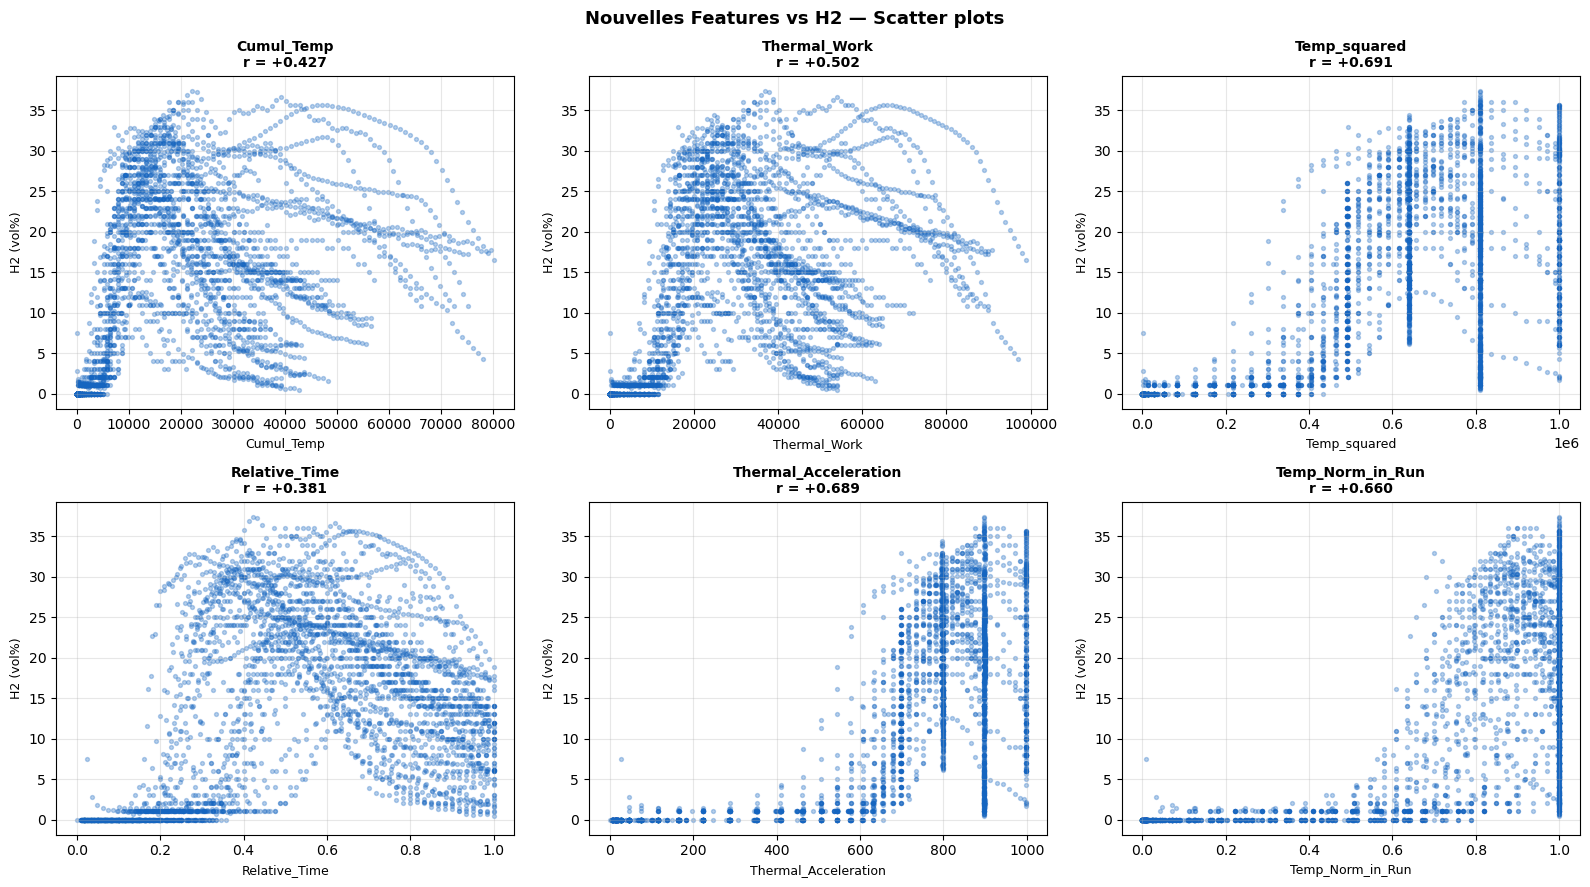

In [4]:
# ── Visualisation des features importantes ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

top_feats = ['Cumul_Temp','Thermal_Work','Temp_squared',
             'Relative_Time','Thermal_Acceleration','Temp_Norm_in_Run']

for ax, feat in zip(axes.flat, top_feats):
    r, _ = stats.pearsonr(df[feat], df['Hydrogen'])
    ax.scatter(df[feat], df['Hydrogen'], alpha=0.3, s=8, color='#1565C0')
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel("H2 (vol%)", fontsize=9)
    ax.set_title(f"{feat}\nr = {r:+.3f}", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle("Nouvelles Features vs H2 — Scatter plots", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [5]:
# ── Résumé final des features ──────────────────────────────────
print(f"Dataset final : {X.shape[0]} lignes × {X.shape[1]} features")
print(f"\nFeatures numériques ({len(num_cols)}) :")
for i, f in enumerate(num_cols):
    print(f"  {i+1:2d}. {f}")
print(f"\nFeatures catégorielles ({len(cat_cols)}) :")
for f in cat_cols:
    print(f"  • {f} -> {df[f].unique().tolist()}")

Dataset final : 3748 lignes × 24 features

Features numériques (21) :
   1. Time
   2. Temperature
   3. ProcessTemperature
   4. AgentFlow
   5. CatalystRatio
   6. Relative_Time
   7. Thermal_Work
   8. Agent_Intensity
   9. Thermal_Acceleration
  10. Relative_Severity
  11. Kinetic_Agent_Density
  12. Cumul_Temp
  13. Temp_Norm_in_Run
  14. Temp_x_AgentFlow
  15. Temp_x_CatalystRatio
  16. Cumul_x_AgentFlow
  17. Temp_squared
  18. Cumul_Temp_squared
  19. Temp_mean_run
  20. Temp_max_run
  21. Temp_std_run

Features catégorielles (3) :
  • AgentType -> ['Air', 'Oxygen']
  • SampleType -> ['TWTS', 'Leather scraps']
  • CatalystType -> ['Marble dust', 'No Catalyst', 'Al-Ni']
